## SQL Database Integration

Sau khi làm việc ban đầu với các file CSV, nhóm đã chuyển dữ liệu vào MySQL để mô phỏng quy trình làm việc thực tế của một dự án Data Science.

Các bước thực hiện:
- Import các file CSV vào MySQL.
- Tạo database `steam_games_db`.
- Tạo các bảng tương ứng với từng file CSV.
- Viết các truy vấn SQL để kiểm tra, thống kê và khám phá dữ liệu.
- Tạo view `vw_applications_ml_base` làm nguồn dữ liệu nền cho các bước EDA và Machine Learning.
- Tạo view `vw_recommendation_base` làm nguồn dữ liệu cho hệ khuyến nghị.

Việc sử dụng MySQL giúp project gần với quy trình thực tế hơn, trong đó SQL được dùng để lưu trữ, truy vấn và chuẩn bị dữ liệu trước khi đưa vào Python để phân tích và xây dựng mô hình.

In [1]:
# TEST SQL
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv("../.env")

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}?charset=utf8mb4"
)

df = pd.read_sql("""
SELECT *
FROM applications
LIMIT 10
""", engine)

df

,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,...,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
0,10,Counter-Strike,game,0,2000-11-01,0,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,None,None,None,None,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,0,1999-04-01,0,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,None,None,None,None,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,0,2003-05-01,0,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,None,None,None,None,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,0,2001-06-01,0,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,None,None,None,None,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,0,1999-11-01,0,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,None,None,None,None,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
5,60,Ricochet,game,0,2000-11-01,0,A futuristic action game that challenges your ...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,None,None,None,None,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
6,70,Half-Life,game,0,1998-11-19,0,Named Game of the Year by over 50 publications...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,None,None,None,None,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
7,80,Counter-Strike: Condition Zero,game,0,2004-03-01,0,"With its extensive Tour of Duty campaign, a ne...","English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,None,None,None,None,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
8,130,Half-Life: Blue Shift,game,0,2001-06-01,0,Made by Gearbox Software and originally releas...,"English, French, German",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,None,None,None,None,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
9,219,Half-Life 2: Demo,demo,1,2004-12-01,0,Half-Life 2 defines a new benchmark in gaming ...,English,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,None,None,None,None,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Đã import các thư viện cần thiết.")

Đã import các thư viện cần thiết.


### Load Data

In [7]:
df = pd.read_csv("../data/raw/applications.csv", low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (239664, 30)


,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
0,10,Counter-Strike,game,False,2000-11-01,0,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,88.0,161854.0,True,True,True,999.0,999.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,False,1999-04-01,0,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,6633.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,False,2003-05-01,0,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,79.0,4308.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,False,2001-06-01,0,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,2338.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,False,1999-11-01,0,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,22793.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


#### thông tin tổng quan

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239664 entries, 0 to 239663
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   appid                  239664 non-null  int64  
 1   name                   239660 non-null  str    
 2   type                   236997 non-null  str    
 3   is_free                239664 non-null  bool   
 4   release_date           202809 non-null  str    
 5   required_age           239664 non-null  str    
 6   short_description      224171 non-null  str    
 7   supported_languages    222006 non-null  str    
 8   header_image           239664 non-null  str    
 9   background             239664 non-null  str    
 10  metacritic_score       5299 non-null    float64
 11  recommendations_total  22560 non-null   float64
 12  mat_supports_windows   239664 non-null  bool   
 13  mat_supports_mac       239664 non-null  bool   
 14  mat_supports_linux     239664 non-null  bool   

#### thống kê mô tả

In [9]:
df.describe(include='all')

,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
count,2.396640e+05,239660,236997,239664,202809,239664,224171,222006,239664,239664,5299.000000,2.256000e+04,239664,239664,239664,1.449230e+05,1.449230e+05,144923.000000,144923,61401.000000,195874,183242,181274,169242,101890,97036,96825,92047,239664,239664
unique,NaN,237760,5,2,5496,21,206930,30503,239576,239664,NaN,NaN,2,2,2,NaN,NaN,NaN,33,NaN,13882,33792,1302,38249,8302,24105,635,26678,2,121
top,NaN,Prism,game,False,2022-05-30,0,Embark on your adventure with player from all ...,English,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,NaN,True,True,True,NaN,NaN,NaN,USD,NaN,Windows 10,1.6 GHz or higher processor,4 GB RAM,Graphics card recommended,Windows 10,2.0 GHz or higher processor,8 GB RAM,DirectX or OpenGL compatible card.,2025-09-07 12:36:43.243384+00:00,2025-09-29 02:01:37.107239+00:00
freq,NaN,6,150279,191390,353,235672,284,54664,53,1,NaN,NaN,239658,239392,239364,NaN,NaN,NaN,142570,NaN,29300,2806,47941,2690,22018,2680,28136,2236,239152,40361
mean,2.032248e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.052651,4.648429e+03,NaN,NaN,NaN,2.265139e+04,2.064869e+04,5.361916,NaN,34.411215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.068241e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.299116,4.642273e+04,NaN,NaN,NaN,8.571831e+05,7.796022e+05,17.769805,NaN,197.958850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,1.010000e+02,NaN,NaN,NaN,5.000000e+01,4.400000e+01,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.122595e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.000000,1.740000e+02,NaN,NaN,NaN,2.990000e+02,2.990000e+02,0.000000,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.993815e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.000000,3.690000e+02,NaN,NaN,NaN,4.990000e+02,4.990000e+02,0.000000,NaN,17.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.946382e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.000000,1.205250e+03,NaN,NaN,NaN,9.990000e+02,9.990000e+02,0.000000,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### kiểm tra missing value

In [10]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

missing_df

,Missing Count,Missing %
metacritic_score,234365,97.788988
recommendations_total,217104,90.586822
mat_achievement_count,178263,74.380383
mat_pc_graphics_rec,147617,61.593314
mat_pc_memory_rec,142839,59.599690
mat_pc_processor_rec,142628,59.511650
mat_pc_os_rec,137774,57.486314
mat_final_price,94741,39.530760
mat_initial_price,94741,39.530760
mat_discount_percent,94741,39.530760


#### visualize missing

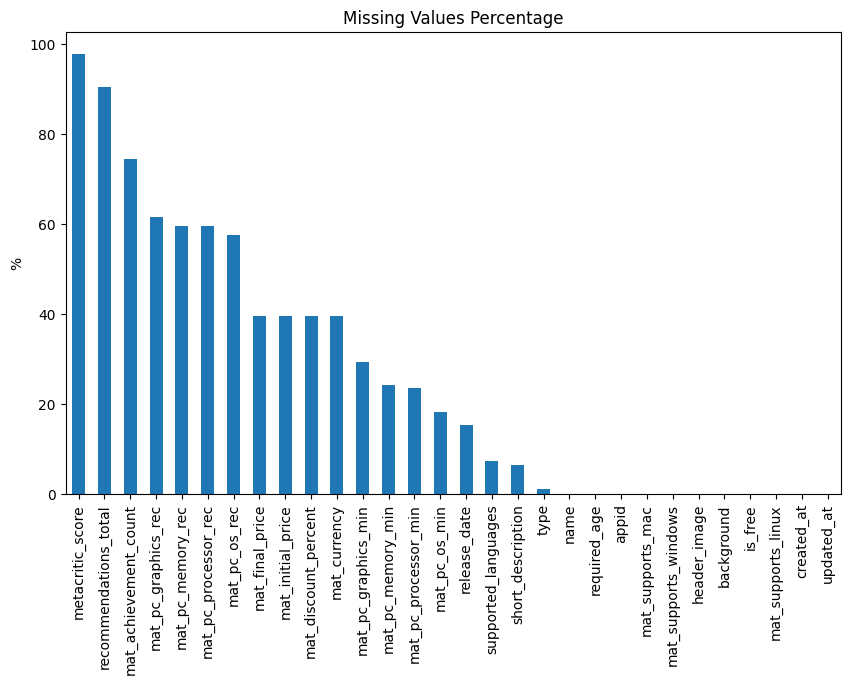

In [11]:
plt.figure(figsize=(10,6))
missing_df['Missing %'].plot(kind='bar')
plt.title("Missing Values Percentage")
plt.ylabel("%")
plt.show()

#### phân tích biến categorical

In [12]:
print("Type distribution:")
print(df['type'].value_counts())

print("\nFree vs Paid:")
print(df['is_free'].value_counts())

Type distribution:
type
game     150279
dlc       53792
demo      23521
music      8713
video       692
Name: count, dtype: int64

Free vs Paid:
is_free
False    191390
True      48274
Name: count, dtype: int64


#### phân tích giá

In [13]:
df['mat_final_price'].describe()

count    1.449230e+05
mean     2.064869e+04
std      7.796022e+05
min      4.400000e+01
25%      2.990000e+02
50%      4.990000e+02
75%      9.990000e+02
max      8.910000e+07
Name: mat_final_price, dtype: float64

#### histogram giá

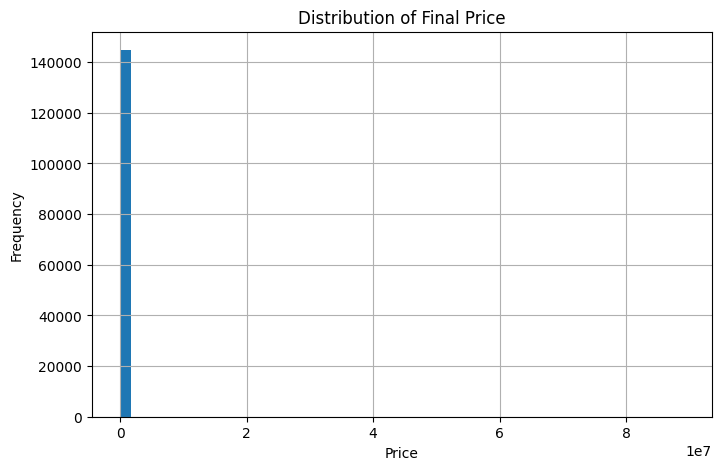

In [14]:
plt.figure(figsize=(8,5))
df['mat_final_price'].hist(bins=50)
plt.title("Distribution of Final Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

#### Discount analysis

In [16]:
df['mat_discount_percent'].describe()

count    144923.000000
mean          5.361916
std          17.769805
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          95.000000
Name: mat_discount_percent, dtype: float64

#### check dữ liệu bất thường

In [17]:
print("Negative price:", (df['mat_final_price'] < 0).sum())
print("Discount > 100%:", (df['mat_discount_percent'] > 100).sum())

Negative price: 0
Discount > 100%: 0


#### check trùng lặp

In [18]:
df.duplicated().sum()

np.int64(0)

#### Correlation (numeric)

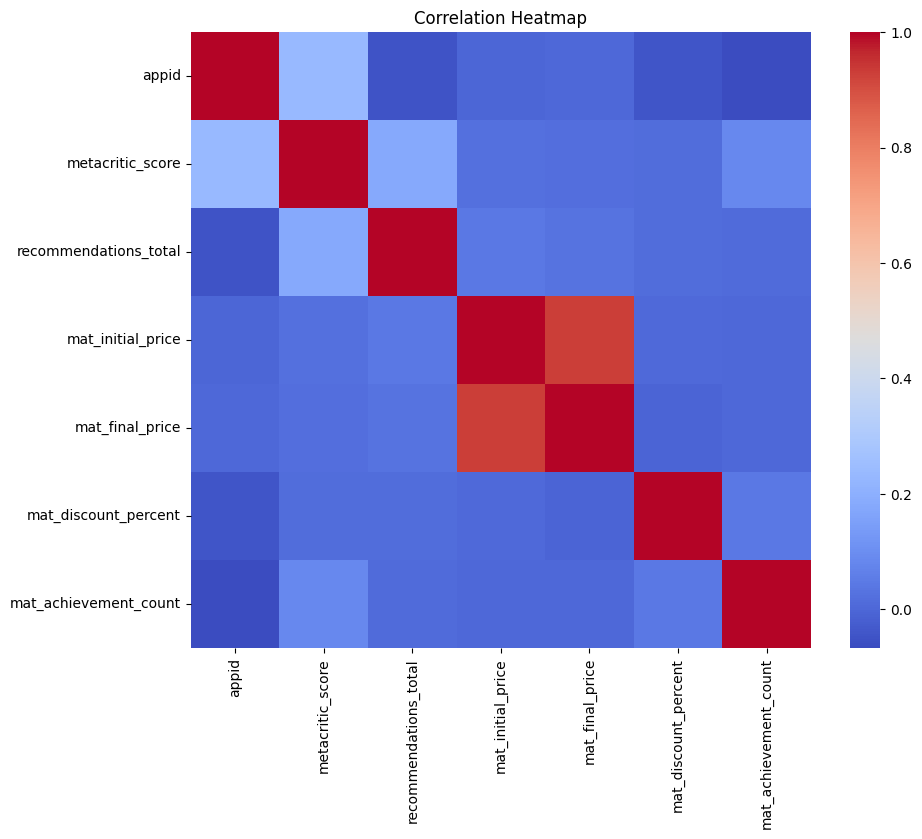

In [20]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### một số insight test nhanh

In [ ]:
# game free có giá không?
df[df['is_free'] == True]['mat_final_price'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: mat_final_price, dtype: float64

In [30]:
# game có review nhiều
df[['recommendations_total']].describe()

,recommendations_total
count,2.256000e+04
mean,4.648429e+03
std,4.642273e+04
min,1.010000e+02
25%,1.740000e+02
50%,3.690000e+02
75%,1.205250e+03
max,4.661011e+06


In [32]:
# game có điểm metacritic
df[['metacritic_score']].describe()

,metacritic_score
count,5299.000000
mean,74.052651
std,10.299116
min,6.000000
25%,69.000000
50%,76.000000
75%,81.000000
max,97.000000


# Kết luận tổng thể

## 1. Tổng quan dữ liệu
- Dataset gồm ~239,000 game với 30 thuộc tính
- Bao gồm thông tin về:
- Giá
- Hệ điều hành
- Mô tả game
- Đánh giá (metacritic, recommendations)
- Cấu hình máy
## 2. Vấn đề missing values
- Rất nhiều cột bị thiếu dữ liệu nghiêm trọng:
- metacritic_score ~ 98% thiếu
- recommendations_total ~ 90% thiếu
- mat_achievement_count ~ 74% thiếu
- Các cột cấu hình "recommended" thiếu ~60%
- Các cột giá thiếu ~40%

Nhận định:
- Nhiều feature không thể dùng trực tiếp
- Cần:
    + Loại bỏ
    + hoặc fill hợp lý
## 3. Dữ liệu giá
- Phần lớn game có giá thấp hoặc free
- Có sự lệch (skewed distribution)
## 4. Dữ liệu categorical
- type có nhiều giá trị nhưng không quá mất cân bằng
- is_free là feature quan trọng
## 5. Dữ liệu bất thường
- Có khả năng tồn tại:
- giá = 0 nhưng không phải free
- discount không hợp lệ (cần kiểm tra thêm)
## 6. Feature tiềm năng

- Các feature có thể dùng:

    + is_free
    + mat_final_price
    + mat_discount_percent
    + mat_supports_windows/mac/linux
    + release_date (có thể convert)
## 7. Hướng xử lý tiếp theo (preprocessing)
- Xử lý missing values:
     + Drop cột thiếu quá nhiều (>70%)
     + Fill các cột quan trọng
     + Convert datatype:
     + required_age → numeric
     + release_date → datetime
- Feature engineering:
     + has_discount
     + price category
- Encode categorical